--- Starting MLP (Multi-Layer Perceptron) Consumption Forecasting ---
--- With Population and Income Growth as Input Features ---
--- Reproducibility Seed Set: 42 ---
Training data: 96 months (2015-01-01 00:00:00 to 2022-12-01 00:00:00)
Test data: 36 months (2023-01-01 00:00:00 to 2025-12-01 00:00:00)

Training MLP with 100 neurons in hidden layers...
Input features: 18 (6 months × 3 variables)


Config: 100 neurons | MAPE: 0.07%

Training MLP with 200 neurons in hidden layers...
Input features: 18 (6 months × 3 variables)
Config: 200 neurons | MAPE: 0.08%

Training MLP with 300 neurons in hidden layers...
Input features: 18 (6 months × 3 variables)
Config: 300 neurons | MAPE: 0.09%

BEST NETWORK CONFIGURATION:
Hidden Layer Neurons: 100
Minimum MAPE: 0.07%
Success! Optimized model saved at: ..\best_mlp_model-multi.h5

--- Generating 10-year Forecast (2026-2035) ---
--- Using Population and Income Growth as Input Features ---


c:\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Success! Future predictions saved at: ..\resultados\previsoes_futuras_2026_2035_MLP-multi.csv
Success! Yearly totals saved at: ..\resultados\previsoes_anuais_2026_2035_MLP.csv


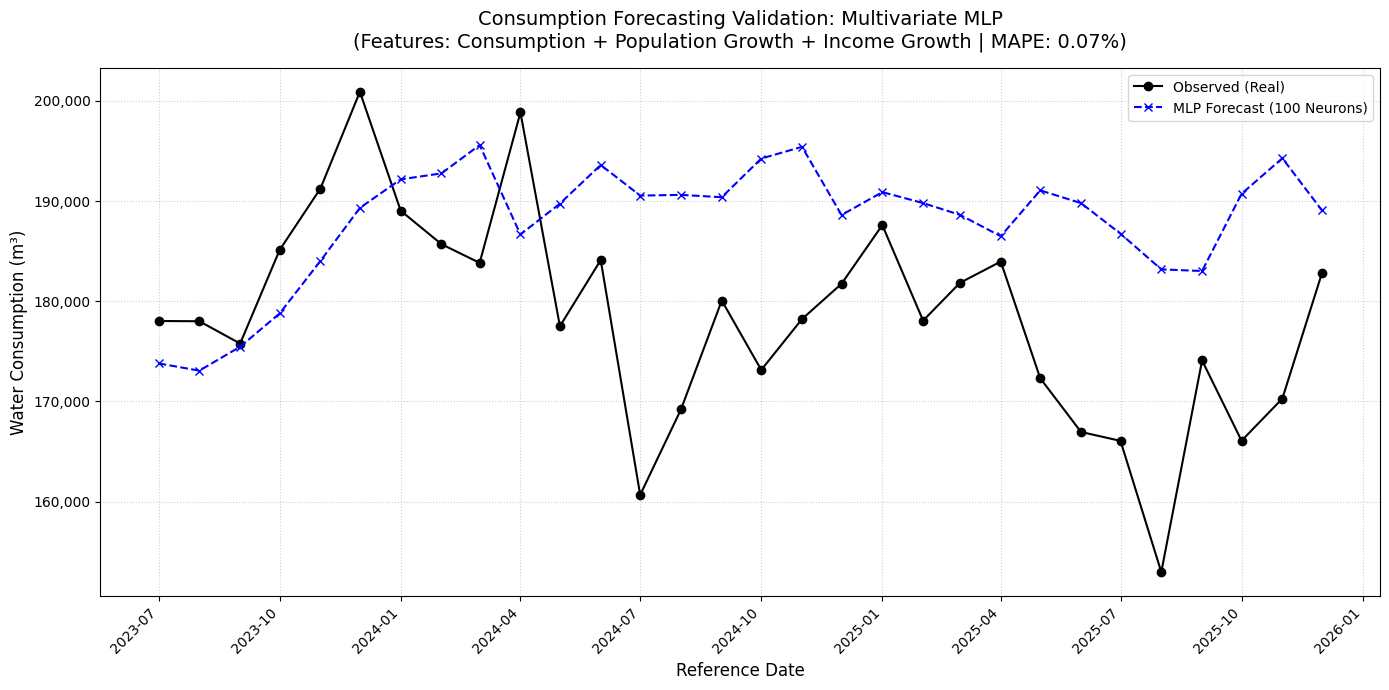


--- Forecast Summary ---
Total consumption 2026-2035: 23,075,381.21 m³
Average monthly consumption: 192,294.84 m³
Maximum monthly consumption: 194,149.76 m³
Minimum monthly consumption: 188,122.64 m³

--- Yearly Totals ---
2026: 2,297,550.61 m³
2027: 2,308,229.12 m³
2028: 2,308,813.19 m³
2029: 2,308,719.10 m³
2030: 2,308,684.11 m³
2031: 2,308,677.67 m³
2032: 2,308,676.89 m³
2033: 2,308,676.84 m³
2034: 2,308,676.84 m³
2035: 2,308,676.84 m³


In [ ]:
import pandas as pd
import numpy as np
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# ==========================================
# 1. Configuration and Reproducibility
# ==========================================
BASE_PATH = '..'
INPUT_FILE = os.path.join(BASE_PATH, 'includes','dados', 'Tabela_consumo_Itapua_120m.csv')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-mlp-forecast-validation-multi.pdf'
MODEL_PATH = os.path.join(BASE_PATH, 'best_mlp_model-multi.h5')
FORECAST_CSV = os.path.join(BASE_PATH, 'modelos IA multi', 'previsoes_futuras_2026_2035_MLP-multi.csv')

# ==========================================
# 1.1 Growth Rates Vectors (2016-2025)
# ==========================================
taxas_crescimento_mensal = [
    0.00034,  # 2016
    0.00034,  # 2017
    0.00035,  # 2018
    0.00034,  # 2019
    0.00032,  # 2020
    0.00030,  # 2021
    0.00029,  # 2022
    0.00027,  # 2023
    0.00025,  # 2024
    0.00023   # 2025
]

percentuais_aumento_renda = [
    -0.040694617,  # 2016
    0.005083616,   # 2017
    0.005261762,   # 2018
    0.009585339,   # 2019
    -0.045615004,  # 2020
    0.039183815,   # 2021
    0.021387542,   # 2022
    0.004332235,   # 2023
    0.045954924,   # 2024
    0.011194       # 2025
]

# Projected growth rates for 2026-2035
taxas_crescimento_mensal_futuro = [0.00025] * 10
percentuais_aumento_renda_futuro = [0.0244] * 10

def set_reproducibility(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"--- Reproducibility Seed Set: {seed} ---")

def mape_loss(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    return tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100

def create_multivariate_dataset(data, look_back=1):
    """
    Converts multivariate time series data into a supervised learning format.
    data: DataFrame with columns ['consumption', 'pop_growth', 'income_growth']
    Returns X (features) and Y (target)
    """
    X, Y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)].values.flatten())
        Y.append(data.iloc[i + look_back]['consumption'])
    return np.array(X), np.array(Y)

def main():
    print("--- Starting MLP (Multi-Layer Perceptron) Consumption Forecasting ---")
    print("--- With Population and Income Growth as Input Features ---")
    set_reproducibility(42)

    # ==========================================
    # 2. Data Loading and Preprocessing
    # ==========================================
    if not os.path.exists(INPUT_FILE):
        print(f"Error: Input file not found at {INPUT_FILE}")
        return

    df = pd.read_csv(INPUT_FILE, sep=';')
    df['AM_REFERENCIA'] = pd.to_datetime(df['AM_REFERENCIA'], format='%Y%m')
    
    df_aggregated = df.groupby('AM_REFERENCIA')['HCLQTCON'].sum().reset_index()
    df_aggregated = df_aggregated.sort_values(by='AM_REFERENCIA')
    
    dates = df_aggregated['AM_REFERENCIA']
    consumption = df_aggregated['HCLQTCON'].values
    
    # ==========================================
    # 3. Create Multivariate Dataset
    # ==========================================
    pop_growth_monthly = []
    inc_growth_monthly = []
    
    # 2015 (use 2016 rates as baseline)
    pop_growth_monthly.extend([taxas_crescimento_mensal[0]] * 12)
    inc_growth_monthly.extend([percentuais_aumento_renda[0]] * 12)
    
    # 2016-2025
    for i in range(10):
        pop_growth_monthly.extend([taxas_crescimento_mensal[i]] * 12)
        inc_growth_monthly.extend([percentuais_aumento_renda[i]] * 12)
    
    n_months = len(consumption)
    pop_growth_monthly = pop_growth_monthly[:n_months]
    inc_growth_monthly = inc_growth_monthly[:n_months]
    
    df_multivariate = pd.DataFrame({
        'date': dates,
        'consumption': consumption,
        'pop_growth': pop_growth_monthly,
        'income_growth': inc_growth_monthly
    })
    
    # ==========================================
    # 4. Data Normalization
    # ==========================================
    scaler = MinMaxScaler()
    features_to_scale = ['consumption', 'pop_growth', 'income_growth']
    df_multivariate[features_to_scale] = scaler.fit_transform(
        df_multivariate[features_to_scale]
    )
    
    # Train-Test Split
    train_mask = (df_multivariate['date'] >= '2015-01-01') & (df_multivariate['date'] <= '2022-12-01')
    test_mask = (df_multivariate['date'] >= '2023-01-01') & (df_multivariate['date'] <= '2025-12-01')
    
    train_data = df_multivariate[train_mask].copy()
    test_data = df_multivariate[test_mask].copy()
    
    print(f"Training data: {len(train_data)} months ({train_data['date'].min()} to {train_data['date'].max()})")
    print(f"Test data: {len(test_data)} months ({test_data['date'].min()} to {test_data['date'].max()})")

    look_back = 6
    
    X_train, Y_train = create_multivariate_dataset(
        train_data[['consumption', 'pop_growth', 'income_growth']], 
        look_back
    )
    X_test, Y_test = create_multivariate_dataset(
        test_data[['consumption', 'pop_growth', 'income_growth']], 
        look_back
    )
    
    if len(X_train) == 0 or len(X_test) == 0:
        print("Error: Insufficient data. Please reduce look_back.")
        return

    # ==========================================
    # 5. Model Training
    # ==========================================
    neurons_list = [100, 200, 300]
    best_mape = float('inf')
    best_config = None
    best_predictions = None
    best_model_obj = None
    
    input_dim = look_back * 3

    for neurons in neurons_list:
        print(f"\nTraining MLP with {neurons} neurons in hidden layers...")
        print(f"Input features: {input_dim} (6 months × 3 variables)")
        
        model = Sequential([
            Dense(neurons, input_dim=input_dim, activation='relu'),
            Dense(neurons // 2, activation='relu'),
            Dense(neurons // 2, activation='relu'),
            Dense(25, activation='relu'),
            Dense(1)
        ])

        optimizer = Adam(learning_rate=0.01)
        model.compile(loss=mape_loss, optimizer=optimizer)
        
        model.fit(X_train, Y_train, epochs=100, batch_size=16, verbose=0)

        predictions_scaled = model.predict(X_test, verbose=0).flatten()
        
        predictions_dummy = np.zeros((len(predictions_scaled), 3))
        predictions_dummy[:, 0] = predictions_scaled
        predictions = scaler.inverse_transform(predictions_dummy)[:, 0]
        
        Y_test_dummy = np.zeros((len(Y_test), 3))
        Y_test_dummy[:, 0] = Y_test
        Y_test_original = scaler.inverse_transform(Y_test_dummy)[:, 0]
        
        mape_val = mape(Y_test_original, predictions)
        print(f"Config: {neurons} neurons | MAPE: {mape_val:.2f}%")

        if mape_val < best_mape:
            best_mape = mape_val
            best_config = neurons
            best_predictions = predictions
            best_model_obj = model

    # ==========================================
    # 6. Save Best Model
    # ==========================================
    print("\n" + "="*30)
    print(f"BEST NETWORK CONFIGURATION:")
    print(f"Hidden Layer Neurons: {best_config}")
    print(f"Minimum MAPE: {best_mape:.2f}%")
    print("="*30)

    if best_model_obj is not None:
        if not os.path.exists(os.path.dirname(MODEL_PATH)):
            os.makedirs(os.path.dirname(MODEL_PATH))
        best_model_obj.save(MODEL_PATH)
        print(f"Success! Optimized model saved at: {MODEL_PATH}")

    # ==========================================
    # 7. Future Forecasting (2026-2035)
    # ==========================================
    print("\n--- Generating 10-year Forecast (2026-2035) ---")
    print("--- Using Population and Income Growth as Input Features ---")
    forecast_horizon = 120
    
    last_sequence = df_multivariate.iloc[-look_back:][['consumption', 'pop_growth', 'income_growth']].values
    
    future_pop_growth = []
    future_inc_growth = []
    
    for year in range(10):
        pop_rate = taxas_crescimento_mensal_futuro[year] if year < len(taxas_crescimento_mensal_futuro) else taxas_crescimento_mensal_futuro[-1]
        inc_rate = percentuais_aumento_renda_futuro[year] if year < len(percentuais_aumento_renda_futuro) else percentuais_aumento_renda_futuro[-1]
        future_pop_growth.extend([pop_rate] * 12)
        future_inc_growth.extend([inc_rate] * 12)
    
    future_predictions_scaled = []
    current_sequence = last_sequence.copy()
    
    for i in range(forecast_horizon):
        input_data = current_sequence.flatten().reshape(1, -1)
        
        pred_scaled = best_model_obj.predict(input_data, verbose=0)[0][0]
        future_predictions_scaled.append(pred_scaled)
        
        new_row = np.array([
            pred_scaled,
            future_pop_growth[i],
            future_inc_growth[i]
        ])
        
        current_sequence = np.vstack([current_sequence[1:], new_row])
    
    predictions_dummy = np.zeros((len(future_predictions_scaled), 3))
    predictions_dummy[:, 0] = future_predictions_scaled
    future_predictions = scaler.inverse_transform(predictions_dummy)[:, 0]
    
    forecast_dates = pd.date_range(start='2026-01-01', periods=forecast_horizon, freq='MS')
    forecast_df = pd.DataFrame({
        'Date': forecast_dates,
        'Predicted_Consumption': future_predictions,
        'Population_Growth_Rate': future_pop_growth,
        'Income_Growth_Rate': future_inc_growth
    })
    
    forecast_df['Year'] = forecast_df['Date'].dt.year
    yearly_totals = forecast_df.groupby('Year')['Predicted_Consumption'].sum().reset_index()
    yearly_totals.columns = ['Year', 'Yearly_Total_Consumption']

    if not os.path.exists(os.path.dirname(FORECAST_CSV)):
        os.makedirs(os.path.dirname(FORECAST_CSV))
    forecast_df.to_csv(FORECAST_CSV, index=False)
    print(f"Success! Future predictions saved at: {FORECAST_CSV}")
    
    yearly_csv = os.path.join(os.path.dirname(FORECAST_CSV), 'previsoes_anuais_2026_2035_MLP.csv')
    yearly_totals.to_csv(yearly_csv, index=False)
    print(f"Success! Yearly totals saved at: {yearly_csv}")

    # ==========================================
    # 7. Visualization (ONLY TEST PERIOD)
    # ==========================================
    test_dates = test_data['date'].iloc[look_back:].values
    comparison_df = pd.DataFrame({
        'Date': test_dates,
        'Real Value': Y_test_original,
        'Predicted Value': best_predictions
    }).set_index('Date')

    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(comparison_df.index, comparison_df['Real Value'], 
            label='Observed (Real)', color='black', marker='o', linestyle='-')
    ax.plot(comparison_df.index, comparison_df['Predicted Value'], 
            label=f'MLP Forecast ({best_config} Neurons)', color='blue', marker='x', linestyle='--')

    ax.set_title(f"Consumption Forecasting Validation: Multivariate MLP\n"
                 f"(Features: Consumption + Population Growth + Income Growth | MAPE: {best_mape:.2f}%)", 
                 fontsize=14, pad=15)
    ax.set_ylabel('Water Consumption (m³)', fontsize=12)
    ax.set_xlabel('Reference Date', fontsize=12)
    
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()

    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    plt.show()

    # Print summary statistics
    print("\n--- Forecast Summary ---")
    print(f"Total consumption 2026-2035: {yearly_totals['Yearly_Total_Consumption'].sum():,.2f} m³")
    print(f"Average monthly consumption: {forecast_df['Predicted_Consumption'].mean():,.2f} m³")
    print(f"Maximum monthly consumption: {forecast_df['Predicted_Consumption'].max():,.2f} m³")
    print(f"Minimum monthly consumption: {forecast_df['Predicted_Consumption'].min():,.2f} m³")
    
    print("\n--- Yearly Totals ---")
    for _, row in yearly_totals.iterrows():
        print(f"{int(row['Year'])}: {row['Yearly_Total_Consumption']:,.2f} m³")

if __name__ == "__main__":
    main()

In [5]:
from tensorflow.keras.models import load_model

# Carregar o modelo MLP
model = load_model(MODEL_PATH, compile=False)

print("=" * 50)
print("ARQUITETURA DO MELHOR MODELO MLP")
print("=" * 50)
model.summary()
print("=" * 50)

ARQUITETURA DO MELHOR MODELO MLP
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 100)               1900      
                                                                 
 dense_1 (Dense)             (None, 50)                5050      
                                                                 
 dense_2 (Dense)             (None, 50)                2550      
                                                                 
 dense_3 (Dense)             (None, 25)                1275      
                                                                 
 dense_4 (Dense)             (None, 1)                 26        
                                                                 
Total params: 10801 (42.19 KB)
Trainable params: 10801 (42.19 KB)
Non-trainable params: 0 (0.00 Byte)
_____________________________________________________